## Run CloudSEN12 models in PRISMA

* Authors: Gonzalo Mateo-García, Manuel Montesino Martin

This tutorial shows how to run `CloudSEN12`cloud detection models in a PRISMA image. It requires the `cloudsen12_models` package.


```
pip install cloudsen12_models georeader-spaceml
```

In [1]:
# cloudsen12_models is not a georeader dependency (it depends on georeader),
# so install it in the running kernel.
%pip install cloudsen12_models


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
from georeader.readers import prisma
from cloudsen12_models import cloudsen12
from georeader import plot

In [3]:
import os
from pathlib import Path

# Resolve the repo-level examples/ folder (works regardless of where the notebook runs from).
EXAMPLES_DIR = next(
    (p / "examples" for p in [Path.cwd(), *Path.cwd().parents] if (p / "examples").is_dir()),
    Path("examples"),
)

# PRISMA L1 product used by this notebook. If it is not already in examples/,
# download it from the Azure container. Provide these as environment
# variables (or CI secrets); see examples/README.md.
SAS_TOKEN = os.environ.get("SAS_TOKEN", "")
AZURE_STORAGE_ACCOUNT = os.environ.get("AZURE_STORAGE_ACCOUNT", "")
CONTAINER = os.environ.get("CONTAINER_NAME", "")

tile = "PRS_L1_STD_OFFL_20241109073054_20241109073059_0001"
file = os.fspath(EXAMPLES_DIR / "PRISMA" / f"{tile}.he5")

if not os.path.exists(file):
    import adlfs
    fs = adlfs.AzureBlobFileSystem(
        account_name=AZURE_STORAGE_ACCOUNT, sas_token=SAS_TOKEN, container=CONTAINER
    )
    path_raster = f"az://{CONTAINER}/PRISMA/raster/{tile}.he5"
    if not fs.exists(path_raster):
        raise FileNotFoundError(f"File {path_raster} does not exist")
    os.makedirs(os.path.dirname(file), exist_ok=True)
    print(f"Downloading {path_raster} -> {file} ...")
    fs.get(path_raster, file)
else:
    print(f"Using local file: {file}")

Using local file: /home/gonzalo/git/georeader/examples/PRISMA/PRS_L1_STD_OFFL_20241109073054_20241109073059_0001.he5


In [4]:
prisma_reader = prisma.PRISMA(file)
prisma_reader


        File: /home/gonzalo/git/georeader/examples/PRISMA/PRS_L1_STD_OFFL_20241109073054_20241109073059_0001.he5
        Bounds: (47.82221221923828, 29.50290870666504, 48.19811248779297, 29.824541091918945)
        Time: 2024-11-09 07:30:54.783000+00:00
        VNIR Range: (np.float32(406.9934), np.float32(977.3654)) 63 bands
        SWIR Range: (np.float32(943.3579), np.float32(2497.1155)) 171 bands
        

In [5]:
from georeader.readers import S2_SAFE_reader

srf = S2_SAFE_reader.read_srf("S2A")
srf

/home/gonzalo/git/georeader/.venv/lib/python3.12/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,B01,B02,B03,B04,B05,B06,B07,B08,B8A,B09,B10,B11,B12
SR_WL,,,,,,,,,,,,,
412,0.001776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
413,0.004073,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
414,0.003626,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
415,0.003515,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
416,0.005729,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2316,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.010984
2317,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.007360
2318,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.006491


In [6]:
%%time
import numpy as np
# Load VNIR-SWIR in prisma units (i.e. radiance units)
vnir = prisma_reader.load_raw(swir_flag=False); print(vnir.shape)
swir = prisma_reader.load_raw(swir_flag=True); print(swir.shape)
vnir_swir = np.moveaxis(np.concatenate((vnir, swir), axis = 2), 2, 0)
# Load VNIR-SWIR central wavelengths
vnir_wvl = prisma_reader.wavelength_vnir[0]
swir_wvl = prisma_reader.wavelength_swir[0]
vnir_swir_wvl = np.concatenate((vnir_wvl, swir_wvl))

(1000, 1000, 63)


(1000, 1000, 171)


CPU times: user 7.7 s, sys: 1.41 s, total: 9.11 s
Wall time: 9.47 s


In [7]:
from georeader import reflectance
s2bands = reflectance.transform_to_srf(vnir_swir, 
                                           srf,
                                           wavelengths_hyperspectral=vnir_swir_wvl,
                                           as_reflectance=True,
                                           observation_date_corr_factor=prisma_reader.observation_date_correction_factor,
                                           verbose=True,
                                           units=prisma_reader.units)
type(s2bands)

2026-06-01 17:12:30(0/13) Processing band B01
2026-06-01 17:12:30	 Loading 7 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(1/13) Processing band B02
2026-06-01 17:12:30	 Loading 12 bands
2026-06-01 17:12:30	 bands loaded, computing tensor


/home/gonzalo/git/georeader/.venv/lib/python3.12/site-packages/pysolar/solartime.py:113: UserWarning: I don't know about leap seconds after 2023
  warnings.warn \


2026-06-01 17:12:30(2/13) Processing band B03
2026-06-01 17:12:30	 Loading 7 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(3/13) Processing band B04
2026-06-01 17:12:30	 Loading 5 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(4/13) Processing band B05
2026-06-01 17:12:30	 Loading 3 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(5/13) Processing band B06
2026-06-01 17:12:30	 Loading 3 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(6/13) Processing band B07
2026-06-01 17:12:30	 Loading 4 bands
2026-06-01 17:12:30	 bands loaded, computing tensor


2026-06-01 17:12:30(7/13) Processing band B08
2026-06-01 17:12:30	 Loading 14 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(8/13) Processing band B8A
2026-06-01 17:12:30	 Loading 5 bands
2026-06-01 17:12:30	 bands loaded, computing tensor
2026-06-01 17:12:30(9/13) Processing band B09
2026-06-01 17:12:31	 Loading 5 bands
2026-06-01 17:12:31	 bands loaded, computing tensor
2026-06-01 17:12:31(10/13) Processing band B10


2026-06-01 17:12:31	 Loading 8 bands
2026-06-01 17:12:31	 bands loaded, computing tensor
2026-06-01 17:12:31(11/13) Processing band B11
2026-06-01 17:12:31	 Loading 14 bands
2026-06-01 17:12:31	 bands loaded, computing tensor
2026-06-01 17:12:31(12/13) Processing band B12
2026-06-01 17:12:31	 Loading 32 bands
2026-06-01 17:12:31	 bands loaded, computing tensor


numpy.ndarray

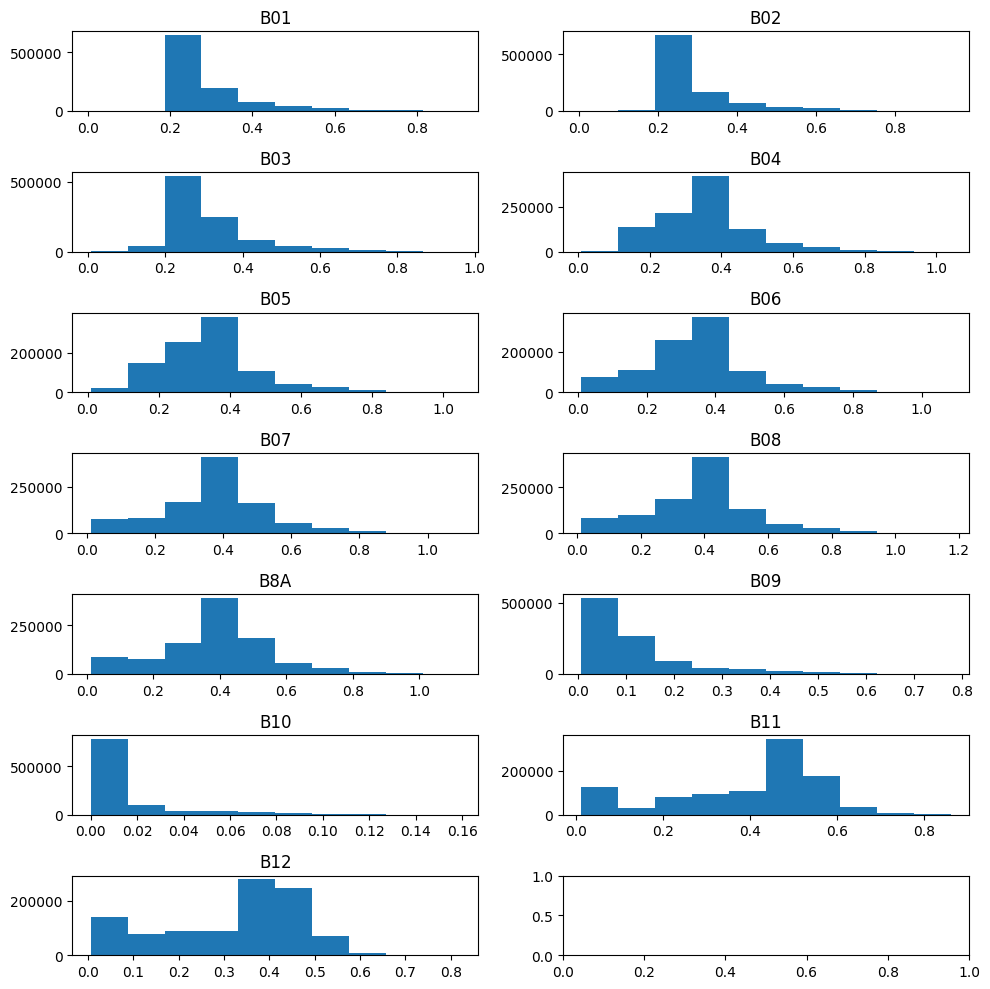

In [8]:
import matplotlib.pyplot as plt

bands_s2 = ["B01","B02","B03","B04","B05","B06","B07","B08","B8A", "B09","B10","B11","B12"]

fig, ax =plt.subplots(7,2,figsize=(10,10), tight_layout=True)
ax =ax.flatten()

for i,b in enumerate(bands_s2):
    ax[i].hist(s2bands[i].ravel())
    ax[i].set_title(b)

In [9]:
s2bands.shape
np.moveaxis(s2bands, 0, 2).astype(np.float32).shape

(1000, 1000, 13)

In [10]:
from georeader import griddata
from georeader.geotensor import GeoTensor
s2_image = griddata.read_to_crs(np.moveaxis(s2bands, 0, 2).astype(np.float32), 
                                lons=prisma_reader.lons, lats=prisma_reader.lats, 
                                resolution_dst=30)
s2_image

 
         Transform: | 30.00, 0.00, 192085.06|
| 0.00,-30.00, 3303421.30|
| 0.00, 0.00, 1.00|
         Shape: (13, 1211, 1235)
         Resolution: (30.0, 30.0)
         Bounds: (192085.06318415108, 3267091.300334674, 229135.06318415108, 3303421.300334674)
         CRS: EPSG:32639
         fill_value_default: -1
        

<Axes: >

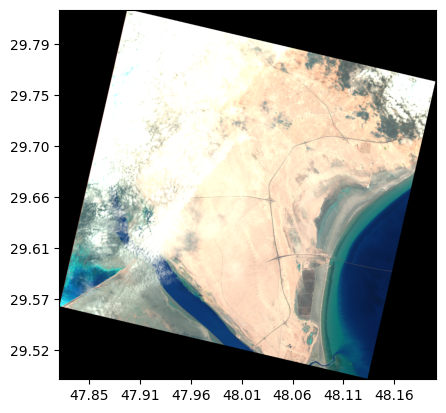

In [11]:
swir_nir_red = (s2_image.isel({"band": [S2_SAFE_reader.BANDS_S2_L1C.index(b) for b in ["B11", "B08", "B04"]]}) / .45).clip(0,1)

plot.show(swir_nir_red)

In [12]:
model_4bands = cloudsen12.load_model_by_name(name="dtacs4bands", weights_folder="cloudsen12_models")
cloudmask = model_4bands.predict(s2bands[[S2_SAFE_reader.BANDS_S2_L1C.index(b) for b in model_4bands.bands]])

cloudmask_geotensor = griddata.read_to_crs(cloudmask,
                                           lons=prisma_reader.lons, lats=prisma_reader.lats, 
                                           resolution_dst=30, method="nearest")

In [13]:
invalids = np.all(swir_nir_red.values == 0,axis=0)
cloudmask_geotensor.values[invalids] = np.nan
# swir_nir_red.values[:, invalids] = np.nan

<Axes: >

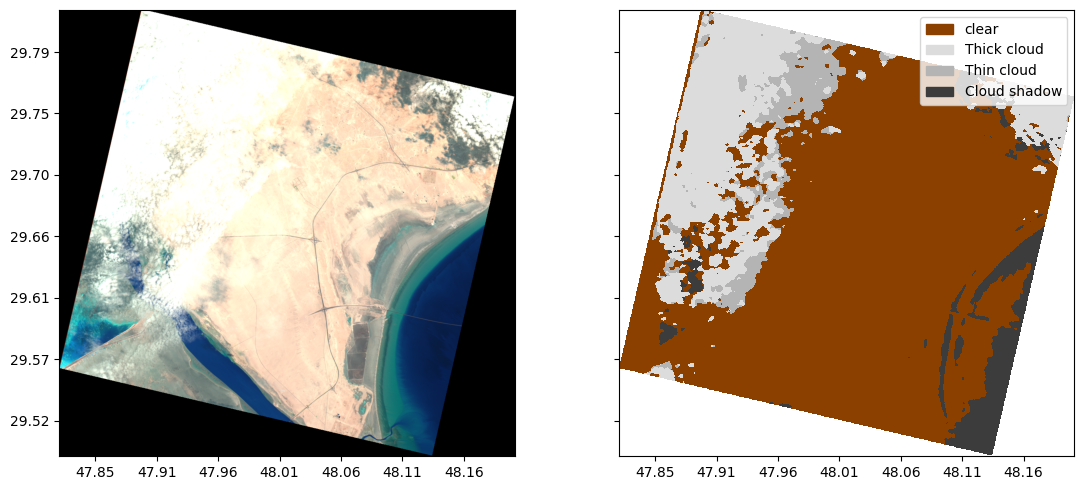

In [14]:
cloudsen12.plot_cloudSEN12mask(cloudmask_geotensor, ax=ax[1])

fig, ax = plt.subplots(1,2,figsize=(14,5),sharey=True, tight_layout=True)

plot.show(swir_nir_red,ax=ax[0])
cloudsen12.plot_cloudSEN12mask(cloudmask_geotensor, ax=ax[1])

## Licence
The `cloudsen12_models` package is published under a [GNU Lesser GPL v3 licence](https://www.gnu.org/licenses/lgpl-3.0.en.html)

The *CloudSEN12* database and all pre-trained models are released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt). For using the models in comercial pipelines written consent by the authors must be provided.

`georeader` tutorials and notebooks are released under a [Creative Commons non-commercial licence](https://creativecommons.org/licenses/by-nc/4.0/legalcode.txt).


 If you find this work useful please cite:
```
@article{aybar_cloudsen12_2024,
	title = {{CloudSEN12}+: {The} largest dataset of expert-labeled pixels for cloud and cloud shadow detection in {Sentinel}-2},
	issn = {2352-3409},
	url = {https://www.sciencedirect.com/science/article/pii/S2352340924008163},
	doi = {10.1016/j.dib.2024.110852},
	journal = {Data in Brief},
	author = {Aybar, Cesar and Bautista, Lesly and Montero, David and Contreras, Julio and Ayala, Daryl and Prudencio, Fernando and Loja, Jhomira and Ysuhuaylas, Luis and Herrera, Fernando and Gonzales, Karen and Valladares, Jeanett and Flores, Lucy A. and Mamani, Evelin and Quiñonez, Maria and Fajardo, Rai and Espinoza, Wendy and Limas, Antonio and Yali, Roy and Alcántara, Alejandro and Leyva, Martin and Loayza-Muro, Rau´l and Willems, Bram and Mateo-García, Gonzalo and Gómez-Chova, Luis},
	month = aug,
	year = {2024},
	pages = {110852},
}
```